Generate 2 stacks per person. 
- First show one stack per person
- Then show the second stack at a later point


People will be presented w/ a stack and find bad ones. 
- If there are some that we are confused about, let's label those also

DUE: Group Meeting on Wednesday 21st; 10:00 am 
- send Sheila receipt for my Lunch for reimbursement

- We want to make things uniform across 3 diff. directions also if possible

- Try to meet with radiolgisti in future???

BAD, BIAS, GOOD


HASTE, BRAIN -- manually look to collect all 3 types 
beginning lower quality than the end


------
For Ellen: 
prepare model-label disalignment examples 
100 slices [50 of each]


(DHCP probably has very good quality slices)

## Finding Pictures for Ellen

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from torch.utils.data import DataLoader
import torch

from model import DiagnosticModel
from data import DicomDataset
from tqdm import tqdm
import pandas as pd

In [2]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')
dataset = DicomDataset(data_dir)
dataloader = DataLoader(dataset, batch_size = 32)
dataset.set_norm(norm_method='min-max', masked_norm=True, perc_norm=0)

Loading People Data: 100%|██████████| 32/32 [00:07<00:00,  4.27it/s]


# Generate DF

In [96]:
model_path = Path('/data/vision/polina/users/marcusbl/bin_class/outputs6/reg/run1/best_model.pth')

model = DiagnosticModel(model_name = 'resnet50')
state_dict = torch.load(model_path, map_location='cpu')  # or 'cuda' if appropriate
model.load_state_dict(state_dict['model_state_dict'])

model.eval()
""

/tmp/ipykernel_3020179/2538840144.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location='cpu')  # or 'cuda' if appropriate


''

In [97]:
all_info = []
global_idx = 0

model.eval()
with torch.no_grad():
    for data, labels in tqdm(dataloader):
        batch_size = labels.size(0)

        batch_indices = np.arange(global_idx, global_idx + batch_size)
        global_idx += batch_size

        data = data.to('cpu')
        labels = labels.to('cpu')

        outputs = model(data)
        probs = torch.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

        error_mask = preds != labels
        error_indices = torch.where(error_mask)[0]

        for i in error_indices:
            dataset_idx = int(batch_indices[i])

            sample = dataset._get_sample(dataset_idx)

            all_info.append({
                "dataset_idx": dataset_idx,
                "nifti_path": sample["nifti_path"],
                "scan_num": sample['scan_num'],
                "label": int(labels[i].item()),
                "pred": int(preds[i].item()),
                "confidence": float(confidences[i].item()),
                "dataset_idx": dataset_idx,
            })


100%|██████████| 229/229 [09:31<00:00,  2.49s/it]


In [ ]:
df = pd.DataFrame(all_info)
df.to_csv(Path('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/df.csv'))

773

# Use DF

In [3]:
df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/df.csv', index_col=0)

In [11]:
df.head(10)

,dataset_idx,nifti_path,scan_num,label,pred,confidence
0,34,/data/vision/polina/users/marcusbl/data/anon-0...,5,1,0,0.805598
1,48,/data/vision/polina/users/marcusbl/data/anon-0...,19,1,0,0.977822
2,50,/data/vision/polina/users/marcusbl/data/anon-0...,21,0,1,0.535669
3,56,/data/vision/polina/users/marcusbl/data/anon-0...,13,1,0,0.558305
4,63,/data/vision/polina/users/marcusbl/data/anon-0...,20,1,0,0.632023
5,68,/data/vision/polina/users/marcusbl/data/anon-0...,4,1,0,0.588719
6,77,/data/vision/polina/users/marcusbl/data/anon-0...,14,1,0,0.854853
7,80,/data/vision/polina/users/marcusbl/data/anon-0...,18,1,0,0.715655
8,91,/data/vision/polina/users/marcusbl/data/anon-0...,5,1,0,0.555083
9,100,/data/vision/polina/users/marcusbl/data/anon-0...,15,1,0,0.935722


# Generating FN / FP

In [109]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
fp_mask = (df['label'] == 0) & (df['pred'] == 1)
fn_mask = (df['label'] == 1) & (df['pred'] == 0)

In [110]:
# FP subset
df_fp = df.loc[fp_mask].copy()
if 'confidence' in df_fp.columns:
    df_fp = df_fp.sort_values(by='confidence', ascending=False)
df_fp = df_fp.reset_index(drop=True)

# FN subset
df_fn = df.loc[fn_mask].copy()
if 'confidence' in df_fn.columns:
    df_fn = df_fn.sort_values(by='confidence', ascending=False)
df_fn = df_fn.reset_index(drop=True)

In [113]:
df_fp.head()

,dataset_idx,nifti_path,scan_num,label,pred,confidence
0,2287,/data/vision/polina/users/marcusbl/data/anon-0...,12,0,1,0.999828
1,1898,/data/vision/polina/users/marcusbl/data/anon-0...,8,0,1,0.997200
2,1573,/data/vision/polina/users/marcusbl/data/anon-0...,31,0,1,0.996653
3,3390,/data/vision/polina/users/marcusbl/data/anon-0...,25,0,1,0.994973
4,2525,/data/vision/polina/users/marcusbl/data/anon-0...,10,0,1,0.993437


In [112]:
df_fn.head()

,dataset_idx,nifti_path,scan_num,label,pred,confidence
0,793,/data/vision/polina/users/marcusbl/data/anon-0...,34,1,0,0.999889
1,842,/data/vision/polina/users/marcusbl/data/anon-0...,36,1,0,0.999838
2,833,/data/vision/polina/users/marcusbl/data/anon-0...,26,1,0,0.999373
3,4842,/data/vision/polina/users/marcusbl/data/anon-0...,10,1,0,0.999230
4,5033,/data/vision/polina/users/marcusbl/data/anon-0...,6,1,0,0.998088


In [117]:
from IPython.display import display, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt


def show_image(df: pd.DataFrame, choices: list, title: str = 'none', idx=0):
    rows = list(df.itertuples())

    print(choices)
    if idx >= len(rows):
        print("All images done!")
        return

    d = rows[idx]
    clear_output(wait=True)

    # Show the image
    plt.figure(figsize=(5,5))
    plt.imshow(dataset[d.dataset_idx][0][0], cmap='gray', vmin=0, vmax=1)
    plt.title(f'{title}_{d.dataset_idx}')
    plt.axis('off')
    plt.show()
    plt.close()

    # Create buttons
    btn_a = widgets.Button(description="Include (A)")
    btn_b = widgets.Button(description="Skip (B)")

    # Display buttons
    display(btn_a, btn_b)

    # Callback functions
    def on_a(b):
        choices.append(d.dataset_idx)
        show_image(df, choices, title, idx+1)

    def on_b(b):
        # choices.append({"dataset_idx": d.dataset_idx, "choice": "b"})
        show_image(df, choices, title, idx+1)

    btn_a.on_click(on_a)
    btn_b.on_click(on_b)

false negatives

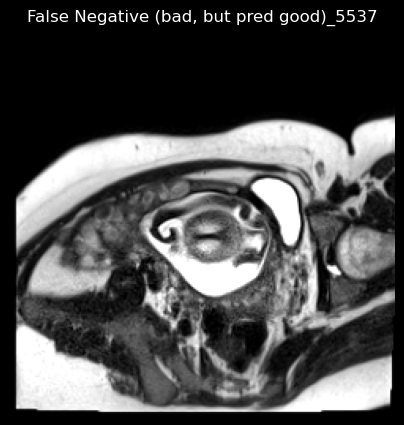

Button(description='Include (A)', style=ButtonStyle())

Button(description='Skip (B)', style=ButtonStyle())

In [ ]:
fn_choices = []
show_image(df_fn, fn_choices, title='False Negative (bad, but pred good)')

In [128]:
print(fn_choices)
print(len(fn_choices))

[793, 842, 833, 4842, 5033, 5074, 4838, 837, 255, 1135, 5073, 779, 259, 592, 1141, 7098, 4763, 3033, 48, 1337, 1243, 1244, 555, 4658, 549, 3946, 5034, 668, 1808, 2594, 2594, 550, 1138, 3792, 2945, 626, 5011, 5057, 4091, 3543, 4617, 1137, 318, 1905, 1279, 6340, 3349, 3793, 2208, 186]
50


In [129]:
df[df['dataset_idx'].isin(fn_choices)].to_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/fn_choices.csv')

false positives

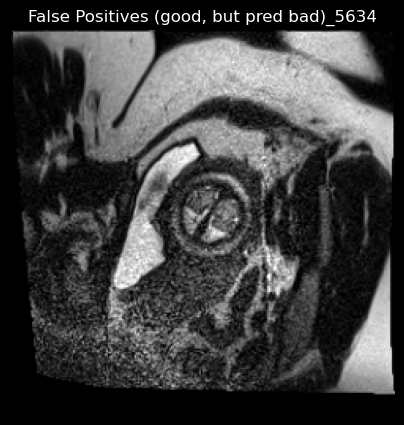

Button(description='Include (A)', style=ButtonStyle())

Button(description='Skip (B)', style=ButtonStyle())

In [130]:
fp_choices = []
show_image(df_fp, fp_choices, title='False Positives (good, but pred bad)')

In [133]:
print(fp_choices)
print(len(fp_choices))

[1898, 1573, 3390, 2525, 6560, 1897, 5414, 1842, 1544, 6677, 2990, 6138, 1046, 2463, 5347, 2352, 3138, 5525, 2354, 1622, 6312, 1323, 1569, 1812, 1899, 5552, 2473, 2447, 1895, 1318, 6146, 2667, 1372, 7253, 1844, 4041, 6206, 1559, 1539, 1633, 1839, 2016, 1540, 1720, 2423, 1191, 2537, 1900, 1546, 1534]
50


In [134]:
df[df['dataset_idx'].isin(fp_choices)].to_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/fp_choices.csv')

# Build Mosaics

In [17]:
fn_choices = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/fn_choices.csv', index_col=0)
fp_choices = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/fp_choices.csv', index_col=0)

In [42]:
choices_df = pd.concat([fn_choices, fp_choices])
choices_df = choices_df.sort_values(by='dataset_idx').reset_index(drop=True)
len(choices_df)

99

In [38]:
choices_df.head()

,dataset_idx,nifti_path,scan_num,label,pred,confidence
0,48,/data/vision/polina/users/marcusbl/data/anon-0...,19,1,0,0.977822
1,186,/data/vision/polina/users/marcusbl/data/anon-0...,11,1,0,0.915942
2,255,/data/vision/polina/users/marcusbl/data/anon-0...,24,1,0,0.995421
3,259,/data/vision/polina/users/marcusbl/data/anon-0...,28,1,0,0.993801
4,318,/data/vision/polina/users/marcusbl/data/anon-0...,16,1,0,0.934082


Save all the images to directory: images/

In [44]:
out_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics')
img_dir = out_dir / 'images'
            
for i, (dataset_idx, data_label) in enumerate(zip(choices_df['dataset_idx'], choices_df['label'])):

    assert dataset[dataset_idx][1] == data_label
    plt.imsave(img_dir / f'scan_{i:03d}.png', dataset[dataset_idx][0][0], cmap='grey')
    

Turn images into a PDF and also save the big csv

In [48]:
from PIL import Image, ImageDraw, ImageFont
import os

output_pdf = out_dir / "all_images.pdf"

# Get image files
image_files = sorted([
    os.path.join(img_dir, f)
    for f in os.listdir(img_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

images = []

# Try to load a default font (portable)
try:
    font = ImageFont.truetype("DejaVuSans.ttf", size=24)
except IOError:
    font = ImageFont.load_default()

for i, f in enumerate(image_files):
    img = Image.open(f).convert("RGB")
    draw = ImageDraw.Draw(img)

    text = f"{i}"
    padding = 20

    # Compute text size
    text_bbox = draw.textbbox((0, 0), text, font=font)
    text_w = text_bbox[2] - text_bbox[0]
    text_h = text_bbox[3] - text_bbox[1]

    # Upper-right corner
    x = img.width - text_w - padding
    y = padding

    draw.text((x, y), text, fill="white", font=font)

    images.append(img)

# Save PDF
images[0].save(
    output_pdf,
    save_all=True,
    append_images=images[1:]
)

print(f"Saved {len(images)} images to {output_pdf}")


Saved 99 images to /data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/all_images.pdf


In [49]:
choices_df.to_csv(out_dir / 'all_choices.csv')